In [ ]:
!pip -q install matplotlib
!pip -q install scipy
!pip -q install mne
!pip -q install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 38.4 MB/s eta 0:00:00


In [ ]:
from mne.time_frequency import psd_array_welch
import mne
import numpy as np
from mne.preprocessing import ICA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
happy_path = '/content/drive/MyDrive/OpenBCI-RAW-2026-01-31_14-45-50 (happy).txt'
sad_path = '/content/drive/MyDrive/OpenBCI-RAW-2026-01-31_15-09-43 (sad).txt'

In [ ]:
sfreq = 125
ch_names = [f'CH{i}' for i in range(1, 17)]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

In [ ]:
data_h = np.loadtxt(happy_path, delimiter=',', skiprows=5, usecols=range(1, 17))
raw_happy = mne.io.RawArray(data_h.T * 1e-6, info)

Creating RawArray with float64 data, n_channels=16, n_times=15545
    Range : 0 ... 15544 =      0.000 ...   124.352 secs
Ready.


In [ ]:
data_s = np.loadtxt(sad_path, delimiter=',', skiprows=5, usecols=range(1, 17))
raw_sad = mne.io.RawArray(data_s.T * 1e-6, info)

Creating RawArray with float64 data, n_channels=16, n_times=11379
    Range : 0 ... 11378 =      0.000 ...    91.024 secs
Ready.


In [ ]:
happy_duration = raw_happy.times[-1]

In [ ]:
raw = mne.concatenate_raws([raw_happy, raw_sad])

In [ ]:
raw.set_eeg_reference('average', projection=False)
raw.filter(l_freq=1, h_freq=40)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (3.304 s)



<RawArray | 16 x 26924 (215.4 s), ~3.3 MiB, data loaded>

In [ ]:
ica = ICA(n_components=15, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = [0]
raw_clean = ica.apply(raw.copy())

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 3.2s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 16 PCA components


/tmp/ipython-input-3848792646.py:2: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (13) and smallest (2.1e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 13
  ica.fit(raw)


In [ ]:
duration = 4
epochs = mne.make_fixed_length_epochs(raw_clean, duration=duration, preload=True)

Not setting metadata
53 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 53 events and 500 original time points ...
1 bad epochs dropped


In [ ]:
n_happy_epochs = int(happy_duration // duration)
labels = np.zeros(len(epochs))
labels[n_happy_epochs:] = 1  # everything after happy is sad

In [ ]:
X = epochs.get_data()

freq_bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 40)}

In [ ]:
def bandpower(data, sfreq, band):
    fmin, fmax = band
    psd, freqs = psd_array_welch(data, sfreq, fmin, fmax, n_fft=125)
    return np.mean(psd, axis=-1)

In [ ]:
features = []
for name, (fmin, fmax) in freq_bands.items():
    bp = bandpower(X, sfreq, (fmin, fmax))
    features.append(bp)

X_features = np.concatenate(features, axis=1)

Effective window size : 1.000 (s)
Effective window size : 1.000 (s)
Effective window size : 1.000 (s)
Effective window size : 1.000 (s)
Effective window size : 1.000 (s)


In [ ]:
# scaling and aplitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.3, random_state=42)

In [ ]:
# svm
svm = SVC(kernel="linear", C=1)
svm.fit(X_train, y_train)
print(f"SVM Accuracy: {svm.score(X_test, y_test)}")

SVM Accuracy: 0.9375


In [ ]:
# finding the best k
k_range = range(1, 10)
scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

best_k = k_range[np.argmax(scores)]
print(f"Best K: {best_k}, Accuracy: {max(scores)}")

Best K: 1, Accuracy: 0.9375


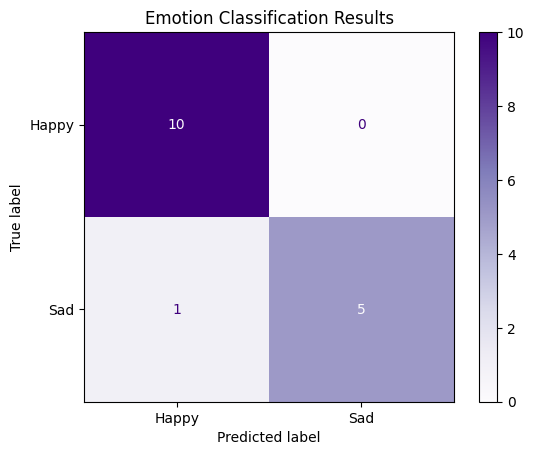

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, svm.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Happy', 'Sad'])
disp.plot(cmap="Purples")
plt.title("Emotion Classification Results")
plt.show()